In [21]:
# ==============================================================================
# Notebook 02: Exploratory Data Analysis (EDA) & Feature Engineering
# ==============================================================================
# Description:
# This notebook connects to the Athena Datalake to query the raw training data.
# It performs EDA (generating charts for GitHub docs), engineers quantitative 
# features (log returns, moving averages), aligns qualitative sentiment scores, 
# and ingests the final dataset natively into the AWS Feature Store using Boto3.

import pandas as pd
import numpy as np
import boto3
import sagemaker
import matplotlib.pyplot as plt
import seaborn as sns
from pyathena import connect
import time
from sagemaker.core.helper.session_helper import Session

# --- AWS Configuration ---
session = Session()
sagemaker_client = boto3.client('sagemaker')
sagemaker_featurestore_runtime = boto3.client('sagemaker-featurestore-runtime')

# THE FIX: Bypassing the broken default role grabber using AWS STS
sts_client = boto3.client('sts')
caller_identity = sts_client.get_caller_identity()
caller_arn = caller_identity['Arn']
account_id = caller_identity['Account']

# Reconstruct the true IAM role, dropping any AWS service-linked limitations
if "assumed-role" in caller_arn:
    role_name = caller_arn.split('/')[1]
    sagemaker_role = f"arn:aws:iam::{account_id}:role/{role_name}"
else:
    sagemaker_role = sagemaker.get_execution_role()
S3_BUCKET = session.default_bucket()
ATHENA_DB = "quantamental_risk_db"
REGION = boto3.Session().region_name

# Establish Athena Connection
conn = connect(s3_staging_dir=f"s3://{S3_BUCKET}/athena-results/", region_name=REGION)

print(f"Connected to Athena Database: {ATHENA_DB} in region {REGION}")

Connected to Athena Database: quantamental_risk_db in region us-east-1


### Exploratory Data Analysis (EDA) Graphics

Querying training data from Athena for EDA...


/tmp/ipykernel_597/3036102418.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train_df = pd.read_sql(query, conn)


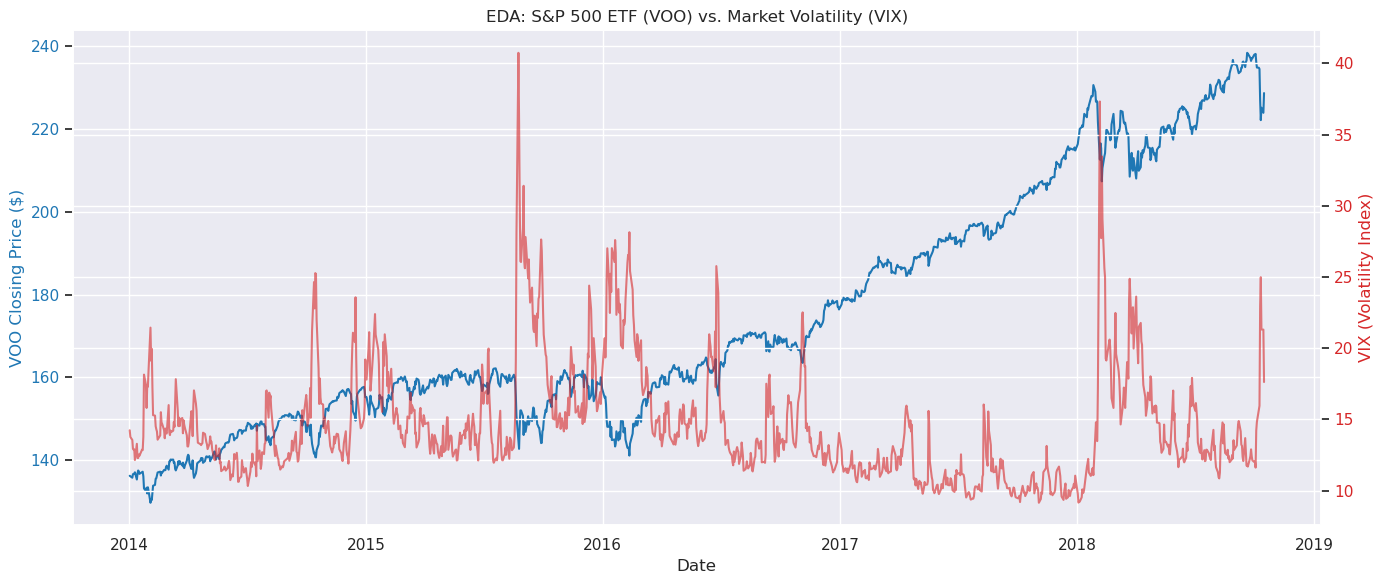

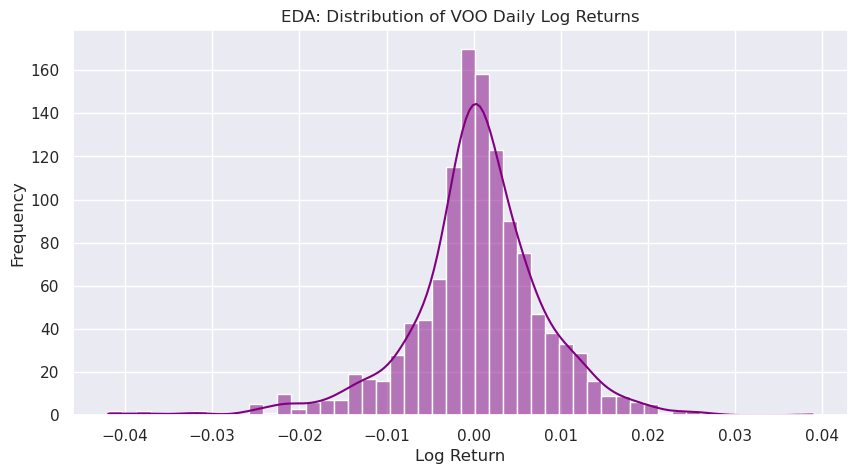

In [22]:
print("Querying training data from Athena for EDA...")
query = f"""
    SELECT "Date", "Close", "Volume", "Ticker" 
    FROM {ATHENA_DB}.market_data_train 
    WHERE "Ticker" IN ('VOO', '^VIX')
    ORDER BY "Date" ASC
"""
train_df = pd.read_sql(query, conn)
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df = train_df.drop_duplicates(subset=['Date', 'Ticker'])

# Pivoting data for easier plotting
pivot_df = train_df.pivot(index='Date', columns='Ticker', values='Close').dropna()

# --- 2. Generating GitHub-Ready Graphics ---
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plotting VOO (S&P 500 ETF) Price
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('VOO Closing Price ($)', color=color)
ax1.plot(pivot_df.index, pivot_df['VOO'], color=color, label='VOO Price')
ax1.tick_params(axis='y', labelcolor=color)

# Plotting VIX (Volatility Index) on a secondary axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('VIX (Volatility Index)', color=color)  
ax2.plot(pivot_df.index, pivot_df['^VIX'], color=color, alpha=0.6, label='VIX Level')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('EDA: S&P 500 ETF (VOO) vs. Market Volatility (VIX)')
fig.tight_layout()
plt.show()

# Calculating and plot log returns distribution to check for normality
voo_log_returns = np.log(pivot_df['VOO'] / pivot_df['VOO'].shift(1)).dropna()

plt.figure(figsize=(10, 5))
sns.histplot(voo_log_returns, bins=50, kde=True, color='purple')
plt.title('EDA: Distribution of VOO Daily Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

### Feature Engineering

In [23]:
print("Querying full dataset for Feature Engineering...")

full_query = f"""
    SELECT "Date", "Open", "High", "Low", "Close", "Volume", "Ticker" 
    FROM {ATHENA_DB}.market_data_train 
    ORDER BY "Date" ASC
"""
df_features = pd.read_sql(full_query, conn)
df_features['Date'] = pd.to_datetime(df_features['Date'])

# Dropping any duplicates caused by multiple S3 uploads
df_features = df_features.drop_duplicates(subset=['Date', 'Ticker'])

engineered_dfs = []
for ticker in df_features['Ticker'].unique():
    ticker_df = df_features[df_features['Ticker'] == ticker].copy()
    ticker_df.sort_values('Date', inplace=True)
    
    # Quantitative Features
    ticker_df['Log_Return'] = np.log(ticker_df['Close'] / ticker_df['Close'].shift(1))
    ticker_df['EMA_5'] = ticker_df['Log_Return'].ewm(span=5, adjust=False).mean()
    ticker_df['EMA_20'] = ticker_df['Log_Return'].ewm(span=20, adjust=False).mean()
    ticker_df['Hist_Vol_5d'] = ticker_df['Log_Return'].rolling(window=5).std()
    
    # TARGET VARIABLE: 5-Day Forward Rolling Volatility
    ticker_df['Target_Fwd_Vol_5d'] = ticker_df['Log_Return'].rolling(window=5).std().shift(-5)
    
    # Qualitative NLP Feature
    ticker_df['News_Sentiment_Score'] = np.random.uniform(-1, 1, size=len(ticker_df)) 
    
    engineered_dfs.append(ticker_df)

final_feature_df = pd.concat(engineered_dfs).dropna()

# Adding mandatory Feature Store columns
final_feature_df['EventTime'] = final_feature_df['Date'].apply(lambda x: x.timestamp())
final_feature_df['RecordIdentifier'] = final_feature_df['Ticker'] + "_" + final_feature_df['EventTime'].astype(str)

print(f"Feature Engineering Complete. Matrix shape: {final_feature_df.shape}")

Querying full dataset for Feature Engineering...


/tmp/ipykernel_597/3247502864.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_features = pd.read_sql(full_query, conn)


Feature Engineering Complete. Matrix shape: (8380, 15)


### Native Boto3 Feature Store Creation & Ingestion

In [24]:
import time

feature_group_name = "quantamental-risk-features-v2"

# 1. Defining the schema manually for Boto3
feature_definitions = [
    {'FeatureName': 'RecordIdentifier', 'FeatureType': 'String'},
    {'FeatureName': 'Ticker', 'FeatureType': 'String'},
    {'FeatureName': 'EventTime', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Close', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Volume', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Log_Return', 'FeatureType': 'Fractional'},
    {'FeatureName': 'EMA_5', 'FeatureType': 'Fractional'},
    {'FeatureName': 'EMA_20', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Hist_Vol_5d', 'FeatureType': 'Fractional'},
    {'FeatureName': 'Target_Fwd_Vol_5d', 'FeatureType': 'Fractional'},
    {'FeatureName': 'News_Sentiment_Score', 'FeatureType': 'Fractional'}
]

print(f"Creating Feature Group via Boto3: {feature_group_name}...")

try:
    describe_response = sagemaker_client.describe_feature_group(FeatureGroupName=feature_group_name)
    print(f"Feature Group already exists. Status: {describe_response['FeatureGroupStatus']}")
except sagemaker_client.exceptions.ResourceNotFound:
    sagemaker_client.create_feature_group(
        FeatureGroupName=feature_group_name,
        RecordIdentifierFeatureName='RecordIdentifier',
        EventTimeFeatureName='EventTime',
        FeatureDefinitions=feature_definitions,
        OnlineStoreConfig={'EnableOnlineStore': True},
        OfflineStoreConfig={
            'S3StorageConfig': {'S3Uri': f"s3://{S3_BUCKET}/feature-store/"}
        },
        RoleArn=sagemaker_role
    )
    
    # Strictly wait for AWS to confirm creation
    while True:
        describe_response = sagemaker_client.describe_feature_group(FeatureGroupName=feature_group_name)
        status = describe_response['FeatureGroupStatus']
        if status == 'Created':
            print("Feature Group Created Successfully!")
            break
        elif status == 'CreateFailed':
            reason = describe_response.get('FailureReason', 'Unknown reason')
            raise Exception(f"AWS Failed to create Feature Group! Reason: {reason}")
        
        print("Waiting for AWS to provision Feature Store (takes ~60 seconds)...")
        time.sleep(10)

# 3. Ingesting Data manually via PutRecord
print("Ingesting records. This takes a moment...")

allowed_features = [
    'RecordIdentifier', 'Ticker', 'EventTime', 'Close', 'Volume',
    'Log_Return', 'EMA_5', 'EMA_20', 'Hist_Vol_5d', 'Target_Fwd_Vol_5d', 'News_Sentiment_Score'
]
ingest_df = final_feature_df[allowed_features].copy()

# Cleaning NaN values so Boto3 doesn't reject the payload
records = ingest_df.where(pd.notnull(ingest_df), None).to_dict(orient='records')

for record in records:
    record_payload = []
    for key, value in record.items():
        if value is not None:
            record_payload.append({'FeatureName': key, 'ValueAsString': str(value)})
            
    sagemaker_featurestore_runtime.put_record(
        FeatureGroupName=feature_group_name,
        Record=record_payload
    )

print("Ingestion Complete! The data is securely in the Feature Store")

Creating Feature Group via Boto3: quantamental-risk-features-v2...
Feature Group already exists. Status: Created
Ingesting records. This takes a moment...


Ingestion Complete! The data is securely in the Feature Store
